In [1]:
# 1 Persiapan Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

In [2]:
# 2 Import Dataset

# Dataset sintetis untuk simulasi (dapat diganti dataset nyata, mis. UCI/Kaggle)
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    weights=[0.8, 0.2],
    random_state=42
)
print("Distribusi kelas:", np.bincount(y))

Distribusi kelas: [797 203]


In [3]:
# 3 Preprocessing: Stratified Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Proporsi kelas train:", np.bincount(y_train) / len(y_train))
print("Proporsi kelas test :", np.bincount(y_test) / len(y_test))

Proporsi kelas train: [0.7975 0.2025]
Proporsi kelas test : [0.795 0.205]


In [4]:
# 4 Training Model & Learning Curve

model = DecisionTreeClassifier(max_depth=4, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy"
)
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

In [5]:
# 5 Evaluasi

print("Skor train pada ukuran data terbesar :", round(train_mean[-1], 3))
print("Skor validasi pada ukuran data terbesar:", round(val_mean[-1], 3))
print("Gap (indikasi overfitting jika besar)  :", round(train_mean[-1] - val_mean[-1], 3))

Skor train pada ukuran data terbesar : 0.929
Skor validasi pada ukuran data terbesar: 0.885
Gap (indikasi overfitting jika besar)  : 0.044


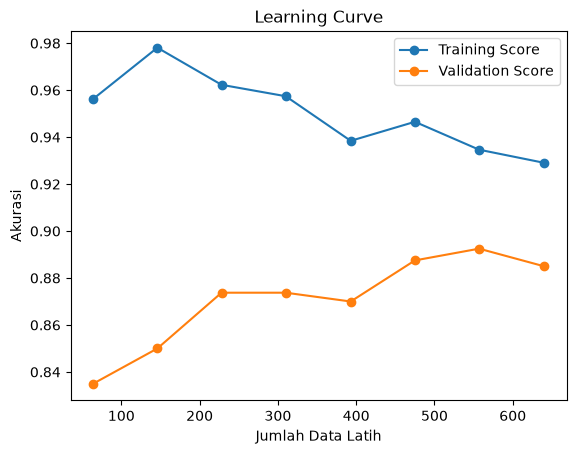

In [6]:
# 6 Visualisasi

plt.plot(train_sizes, train_mean, 'o-', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', label='Validation Score')
plt.xlabel('Jumlah Data Latih')
plt.ylabel('Akurasi')
plt.title('Learning Curve')
plt.legend()
plt.show()